# Loading and Analyzing Old Experiment Data

Load saved `.h5` files as their original experiment objects using `ExperimentClass.from_h5file(path)`, then call `analyze()` and `display()` directly.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from slab_qick_calib.experiments.single_qubit.t1 import T1Experiment
from slab_qick_calib.experiments.single_qubit.rabi import RabiExperiment
from slab_qick_calib.experiments.single_qubit.t2 import T2Experiment
from slab_qick_calib.experiments.single_qubit.resonator_spectroscopy import ResSpecPower
from slab_qick_calib.helpers import handy
%matplotlib inline
handy.config_figs()
DATA_DIR = "C:/_Data/sample_50/" #data"

## 1. T1 Experiment

Load a T1 file as a `T1Experiment` object, re-analyze, and display using its own methods.

R2:0.980	Fit par error:0.021	 Best fit:b'avgi'


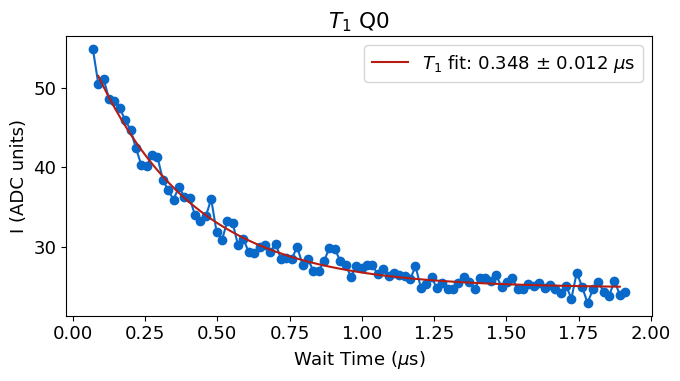

In [15]:
t1 = T1Experiment.from_h5file(f"{DATA_DIR}/t1_qubit0_00011.h5")
t1.analyze(get_hist=False)
t1.display()

## 2. Rabi Experiment

R2:0.897	Fit par error:0.490	 Best fit:b'amps'


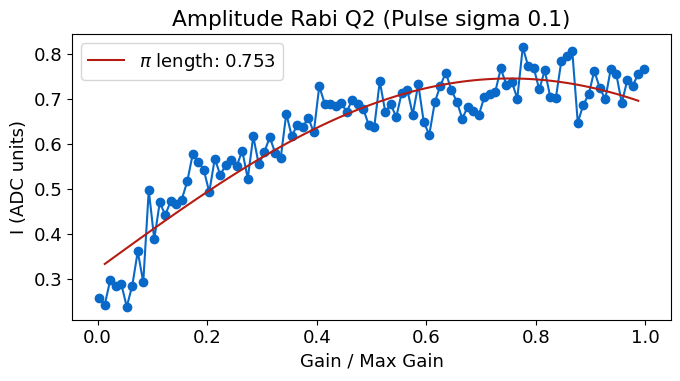

In [16]:
rabi = RabiExperiment.from_h5file(f"{DATA_DIR}/amp_rabi_qubit2_00008.h5")
rabi.analyze(get_hist=False)
rabi.display()

## 3. Ramsey (T2) Experiment

R2:0.868	Fit par error:0.073	 Best fit:b'avgi'


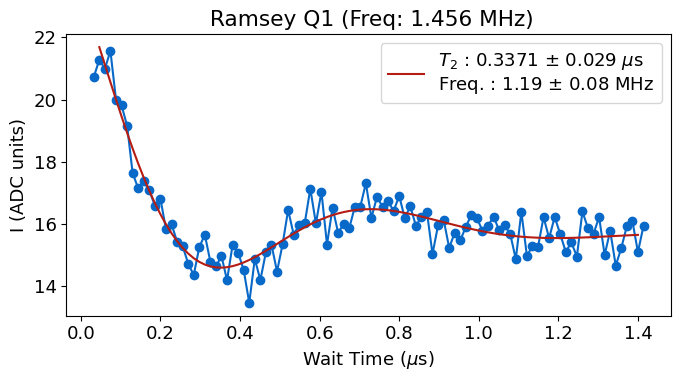

In [17]:
ramsey = T2Experiment.from_h5file(f"{DATA_DIR}/ramsey_qubit1_00008.h5")
ramsey.analyze(get_hist=False)
ramsey.display()

## 4. Qubit Power Spectroscopy

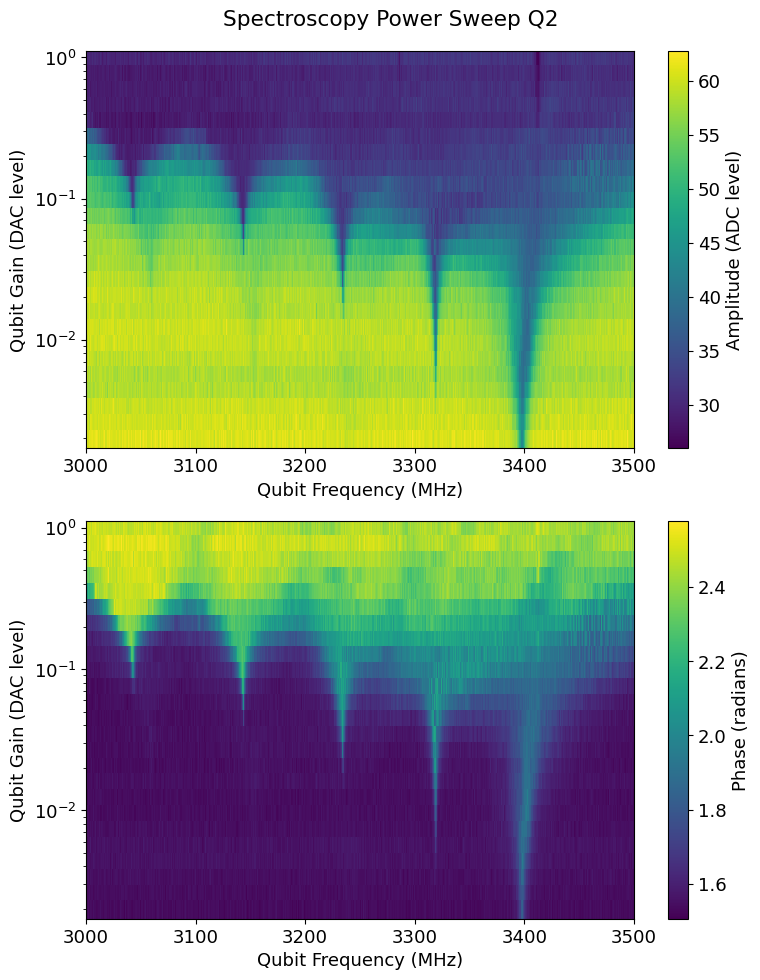

In [57]:
DATA_DIR = "C:/_Data/sample_50/data"
from slab_qick_calib.experiments.single_qubit.pulse_probe_spectroscopy import QubitSpecPower

#qsp = QubitSpecPower.from_h5file(f"{DATA_DIR}/qubit_spectroscopy_power_coarse_qubit1_00004.h5")
qsp = QubitSpecPower.from_h5file(f"{DATA_DIR}/qubit_spectroscopy_power_coarse_qubit2_00001.h5")
qsp.analyze()
qsp.display()

=== 2D (summed over all gains) — top 6 peaks ===
  1. 3042.0 MHz
  2. 3154.2 MHz
  3. 3234.7 MHz
  4. 3319.3 MHz
  5. 3379.4 MHz
  6. 3398.4 MHz

=== 1D (max-gain row, gain=1.000) — top 6 peaks ===
  1. 3138.6 MHz
  2. 3211.7 MHz
  3. 3257.8 MHz
  4. 3334.3 MHz
  5. 3378.4 MHz
  6. 3412.4 MHz

top6_2d = [3042. , 3154.2, 3234.7, 3319.3, 3379.4, 3398.4]
top6_1d = [3138.6, 3211.7, 3257.8, 3334.3, 3378.4, 3412.4]


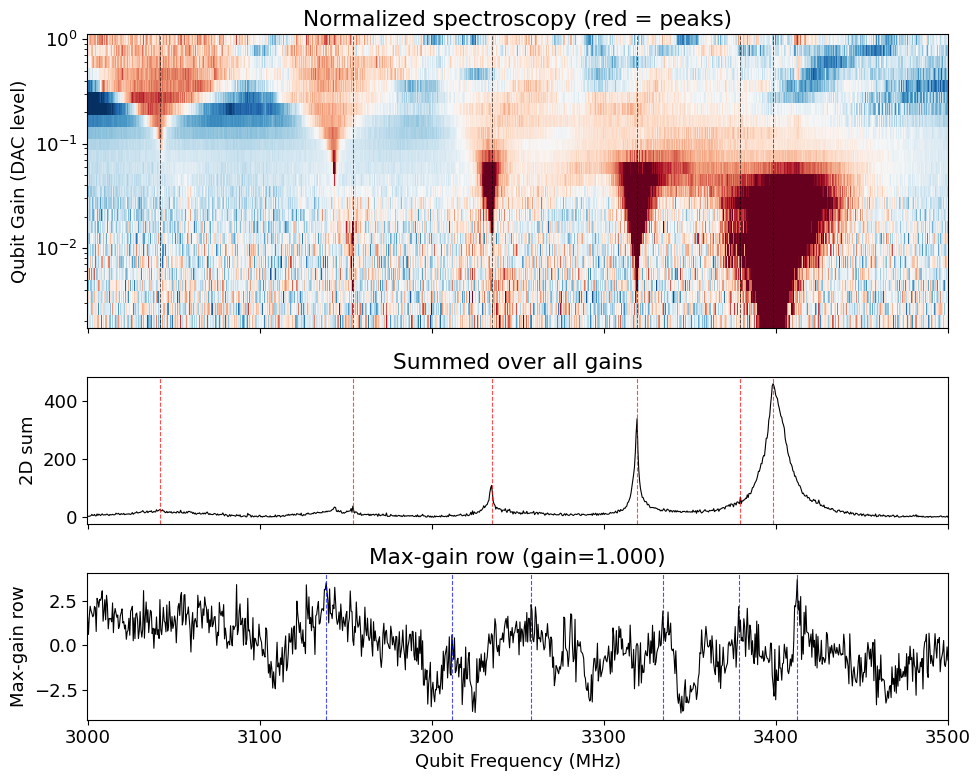

In [59]:
# Find peak frequencies across the full 2D power spectroscopy dataset.
from scipy.signal import find_peaks

amps = qsp.data["phases"]
xpts = qsp.data["xpts"]
ypts = qsp.data["ypts"]

# Normalize each row: subtract median, divide by MAD
normed = np.zeros_like(amps)
for i in range(amps.shape[0]):
    row = amps[i]
    med = np.median(row)
    mad = np.median(np.abs(row - med))
    if mad > 0:
        normed[i] = (row - med) / mad
    else:
        normed[i] = row - med

# ypts is descending: row 0 = max gain, row -1 = min gain
max_gain_idx = 0

# --- 2D analysis: sum positive deviations across all gains ---
peak_strength = np.sum(np.clip(normed, 0, None), axis=0)
p_2d, pr_2d = find_peaks(peak_strength, distance=10, prominence=0)
order_2d = np.argsort(pr_2d["prominences"])[::-1]
p_2d_sorted = p_2d[order_2d]
top6_2d = np.sort(xpts[p_2d_sorted[:6]])

print("=== 2D (summed over all gains) — top 6 peaks ===")
for i, f in enumerate(top6_2d):
    print(f"  {i+1}. {f:.1f} MHz")

# --- 1D analysis: max-gain row (row 0) ---
max_gain_trace = normed[max_gain_idx]
p_1d, pr_1d = find_peaks(max_gain_trace, distance=10, prominence=0)
order_1d = np.argsort(pr_1d["prominences"])[::-1]
p_1d_sorted = p_1d[order_1d]
top6_1d = np.sort(xpts[p_1d_sorted[:6]])

print(f"\n=== 1D (max-gain row, gain={ypts[max_gain_idx]:.3f}) — top 6 peaks ===")
for i, f in enumerate(top6_1d):
    print(f"  {i+1}. {f:.1f} MHz")

print(f"\ntop6_2d = {np.array2string(top6_2d, precision=1, separator=', ')}")
print(f"top6_1d = {np.array2string(top6_1d, precision=1, separator=', ')}")

# --- Visualization ---
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1, 1]})

ax = axes[0]
ax.pcolormesh(xpts, ypts, normed, shading="auto", cmap="RdBu_r", vmin=-5, vmax=5)
ax.set_yscale("log")
ax.set_ylabel("Qubit Gain (DAC level)")
ax.set_title("Normalized spectroscopy (red = peaks)")
for f in top6_2d:
    ax.axvline(f, color="k", ls="--", lw=0.7, alpha=0.6)

ax = axes[1]
ax.plot(xpts, peak_strength, "k-", lw=0.8)
ax.set_ylabel("2D sum")
ax.set_title("Summed over all gains")
for f in top6_2d:
    ax.axvline(f, color="r", ls="--", lw=0.8, alpha=0.7)

ax = axes[2]
ax.plot(xpts, max_gain_trace, "k-", lw=0.8)
ax.set_ylabel("Max-gain row")
ax.set_xlabel("Qubit Frequency (MHz)")
ax.set_title(f"Max-gain row (gain={ypts[max_gain_idx]:.3f})")
for f in top6_1d:
    ax.axvline(f, color="b", ls="--", lw=0.8, alpha=0.7)

plt.tight_layout()
plt.show()


In [45]:
all_the_peaks = np.array([4147.5, 4238.1, 4321.2, 4402.8, 4477.4, 4543.9])
np.diff(all_the_peaks)


array([90.6, 83.1, 81.6, 74.6, 66.5])

In [61]:
all_the_peaks = np.array([3042. , 3154.2, 3234.7, 3319.3,3398.4])
np.diff(all_the_peaks)


array([112.2,  80.5,  84.6,  79.1])

In [62]:
84.6+ 79.1

163.7

In [50]:
74.6+66.5
81.6+ 74.6
90.6+ 83.1

173.7

## 5. Compare multiple T1 measurements

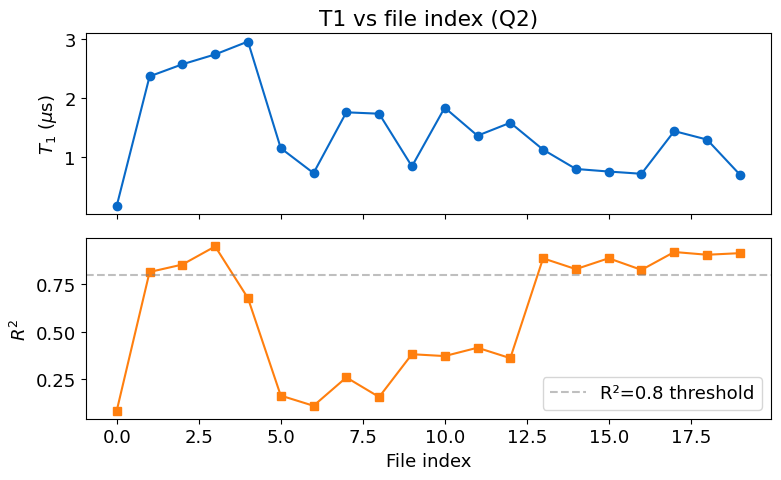

In [21]:
t1_results = []
for i in range(20):
    fpath = f"{DATA_DIR}/t1_qubit2_{i:05d}.h5"
    try:
        exp = T1Experiment.from_h5file(fpath)
        exp.analyze(verbose=False, get_hist=False)
        t1_results.append({
            "index": i,
            "T1": exp.data["new_t1"],
            "r2": exp.data["r2"],
        })
    except Exception:
        pass

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
indices = [r["index"] for r in t1_results]
t1_vals = [r["T1"] for r in t1_results]
r2_vals = [r["r2"] for r in t1_results]

ax1.plot(indices, t1_vals, "o-")
ax1.set_ylabel("$T_1$ ($\\mu$s)")
ax1.set_title("T1 vs file index (Q2)")

ax2.plot(indices, r2_vals, "s-", color="tab:orange")
ax2.set_ylabel("$R^2$")
ax2.set_xlabel("File index")
ax2.axhline(0.8, color="gray", ls="--", alpha=0.5, label="R²=0.8 threshold")
ax2.legend()
plt.tight_layout()
plt.show()

R2:0.868	Fit par error:0.073	 Best fit:b'avgi'


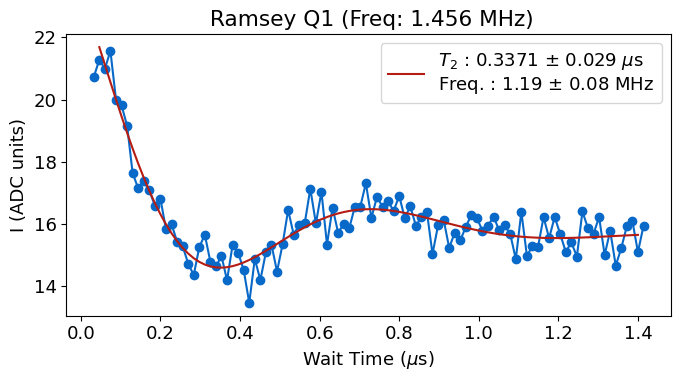

In [22]:
ramsey = T2Experiment.from_h5file(f"{DATA_DIR}/ramsey_qubit1_00008.h5")
ramsey.analyze(get_hist=False)
ramsey.display()

## 6. Resonator Power Sweep

High power peak [MHz]: 7674.8584
Low power peak [MHz]: 7682.4010
Lamb shift [MHz]: -7.5425


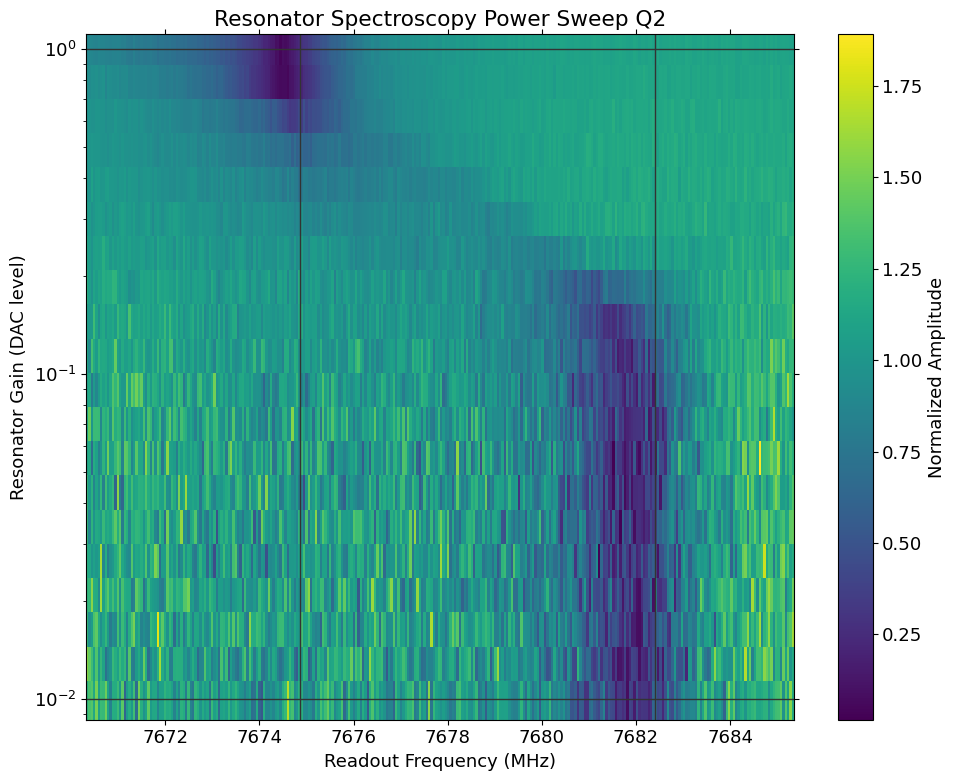

In [41]:
#rsp = ResSpecPower.from_h5file(f"{DATA_DIR}/resonator_spectroscopy_power_sweep_qubit1_00003.h5")
rsp = ResSpecPower.from_h5file(f"{DATA_DIR}/resonator_spectroscopy_power_sweep_qubit2_00004.h5")
rsp.analyze()
rsp.display()

In [24]:
rsp.data['amps'].shape

(76, 300)

Gain range: 0.0100 to 1.0000  (20 steps, log-spaced)

Low-gain resonance frequency: 7681.8737 MHz
  (over gains 0.0100 – 0.0886)
High-gain resonance frequency: 7675.8303 MHz
  (over gains 0.1129 – 1.0000)



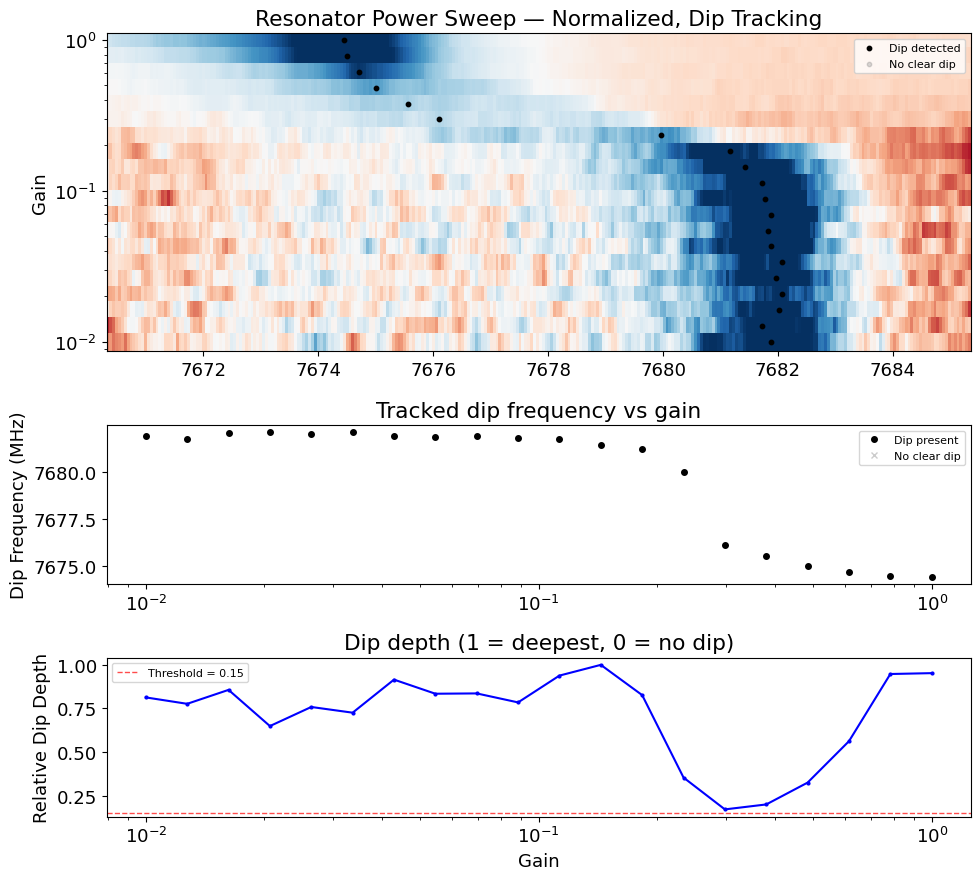

In [42]:

# --- Resonator power sweep: track the dip across gains ---
from scipy.ndimage import uniform_filter1d

amps = rsp.data['amps']      # shape (n_gains, n_freqs)
xpts = rsp.data['xpts']      # frequencies in MHz
gain_pts = rsp.data['gain_pts']  # gain values

n_gains, n_freqs = amps.shape

# Sort by gain (ascending)
sort_idx = np.argsort(gain_pts)
gains_sorted = gain_pts[sort_idx]
amps_sorted = amps[sort_idx]

# Normalize each row: subtract median, divide by MAD
normed = np.zeros_like(amps_sorted)
for i in range(n_gains):
    row = uniform_filter1d(amps_sorted[i], size=5)
    med = np.median(row)
    mad = np.median(np.abs(row - med))
    normed[i] = (row - med) / mad if mad > 0 else row - med

# For each gain, find the deepest dip in normalized data
dip_freqs = np.full(n_gains, np.nan)
dip_depths = np.full(n_gains, np.nan)  # will be negative for dips

for i in range(n_gains):
    min_idx = np.argmin(normed[i])
    dip_freqs[i] = xpts[min_idx]
    dip_depths[i] = normed[i, min_idx]

# Relative dip strength: most negative = strongest dip -> rel_depth=1
max_depth = np.min(dip_depths)
rel_depth = dip_depths / max_depth  # 1 = deepest, ~0 = no dip

# Threshold for "resonance present"
threshold = 0.15
present = rel_depth > threshold

# Find transitions: present -> absent -> present
transitions = np.diff(present.astype(int))
disappear_idx = np.where(transitions == -1)[0]
reappear_idx = np.where(transitions == 1)[0]

print(f"Gain range: {gains_sorted[0]:.4f} to {gains_sorted[-1]:.4f}  ({n_gains} steps, log-spaced)")
print()

# Low-gain resonance frequency
low_gain_present = np.where(present[:n_gains//2])[0]
if len(low_gain_present) > 0:
    low_gain_freq = np.median(dip_freqs[low_gain_present])
    print(f"Low-gain resonance frequency: {low_gain_freq:.4f} MHz")
    print(f"  (over gains {gains_sorted[low_gain_present[0]]:.4f} – {gains_sorted[low_gain_present[-1]]:.4f})")

# High-gain resonance frequency
high_gain_present = np.where(present[n_gains//2:])[0] + n_gains//2
if len(high_gain_present) > 0:
    high_gain_freq = np.median(dip_freqs[high_gain_present])
    print(f"High-gain resonance frequency: {high_gain_freq:.4f} MHz")
    print(f"  (over gains {gains_sorted[high_gain_present[0]]:.4f} – {gains_sorted[high_gain_present[-1]]:.4f})")

print()
g_disappear = g_reappear = None
if len(disappear_idx) > 0:
    g_disappear = gains_sorted[disappear_idx[0]]
    print(f"Resonance DISAPPEARS at gain ~ {g_disappear:.4f}"
          f" (between {gains_sorted[disappear_idx[0]]:.4f} and {gains_sorted[disappear_idx[0]+1]:.4f})")
if len(reappear_idx) > 0:
    for ri in reappear_idx:
        if len(disappear_idx) == 0 or ri > disappear_idx[0]:
            g_reappear = gains_sorted[ri + 1]
            print(f"Resonance REAPPEARS  at gain ~ {g_reappear:.4f}"
                  f" (between {gains_sorted[ri]:.4f} and {gains_sorted[ri+1]:.4f})")
            break

if g_disappear is not None and g_reappear is not None:
    print(f"\nNo-resonance gap: gain {g_disappear:.4f} – {g_reappear:.4f}")

# --- Plots (normalized data, log-scale gain axis) ---
fig, axes = plt.subplots(3, 1, figsize=(10, 9), gridspec_kw={"height_ratios": [2, 1, 1]})

# Panel 1: normalized 2D color plot
ax = axes[0]
ax.pcolormesh(xpts, gains_sorted, normed, shading="auto", cmap="RdBu_r", vmin=-5, vmax=5)
ax.set_yscale("log")
ax.scatter(dip_freqs[present], gains_sorted[present], c='k', s=10, zorder=3, label='Dip detected')
ax.scatter(dip_freqs[~present], gains_sorted[~present], c='gray', s=10, alpha=0.3, zorder=3, label='No clear dip')
if g_disappear is not None:
    ax.axhline(g_disappear, color='orange', ls='--', lw=1.5, label=f'Disappears ~{g_disappear:.4f}')
if g_reappear is not None:
    ax.axhline(g_reappear, color='lime', ls='--', lw=1.5, label=f'Reappears ~{g_reappear:.4f}')
ax.set_ylabel("Gain")
ax.set_title("Resonator Power Sweep — Normalized, Dip Tracking")
ax.legend(fontsize=8, loc='upper right')

# Panel 2: dip frequency vs gain (log x)
ax = axes[1]
ax.semilogx(gains_sorted[present], dip_freqs[present], 'ko', ms=4, label='Dip present')
ax.semilogx(gains_sorted[~present], dip_freqs[~present], 'x', color='gray', ms=4, alpha=0.4, label='No clear dip')
ax.set_ylabel("Dip Frequency (MHz)")
ax.set_title("Tracked dip frequency vs gain")
ax.legend(fontsize=8)

# Panel 3: relative dip depth vs gain (log x)
ax = axes[2]
ax.semilogx(gains_sorted, rel_depth, 'b.-', ms=4)
ax.axhline(threshold, color='r', ls='--', lw=1, alpha=0.7, label=f'Threshold = {threshold}')
ax.set_ylabel("Relative Dip Depth")
ax.set_xlabel("Gain")
ax.set_title("Dip depth (1 = deepest, 0 = no dip)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
